## Importing Libraries

In [2]:
import boto3
import sagemaker
import pandas as pd
import numpy as np
import io
from sagemaker import get_execution_role
from sagemaker.inputs import TrainingInput
from sagemaker.estimator import Estimator

role   = get_execution_role()
sess   = sagemaker.Session()
region = sess.boto_region_name
bucket = 'week8-ali'

print(f"Region : {region}")
print(f"Bucket : {bucket}")
print(f"Role   : {role}")

# Verify your uploaded files are visible in S3
s3 = boto3.client('s3')
response = s3.list_objects_v2(Bucket=bucket)
print("\nFiles found in S3 bucket:")
for obj in response.get('Contents', []):
    # S3 paths — files are directly in the bucket root (no subfolder)
train_s3_uri = f's3://{bucket}/train.csv'
val_s3_uri   = f's3://{bucket}/validation.csv'
test_s3_uri  = f's3://{bucket}/test.csv'

print("Train path      :", train_s3_uri)
print("Validation path :", val_s3_uri)
print("Test path       :", test_s3_uri)

# Quick sanity check — load first 5 rows of train from S3
obj    = s3.get_object(Bucket=bucket, Key='train.csv')
sample = pd.read_csv(io.BytesIO(obj['Body'].read()), header=None, nrows=5)
print(f"\nTrain sample shape : {sample.shape}")
print(f"First column (label) unique values : {sample.iloc[:, 0].unique()}")
print(sample)print(f"  {obj['Key']}  —  {obj['Size']} bytes")

Region : us-east-1
Bucket : week8-ali
Role   : arn:aws:iam::504649076991:role/Ali-SageMakerExecutionRole

Files found in S3 bucket:
  test.csv  —  169958 bytes
  train.csv  —  1164850 bytes
  validation.csv  —  169382 bytes


In [4]:
# S3 paths — files are directly in bucket root (no subfolders)
train_s3_uri = f's3://{bucket}/train.csv'
val_s3_uri   = f's3://{bucket}/validation.csv'
test_s3_uri  = f's3://{bucket}/test.csv'

print("Train path      :", train_s3_uri)
print("Validation path :", val_s3_uri)
print("Test path       :", test_s3_uri)

# Sanity check — load first 5 rows of train from S3
obj    = s3.get_object(Bucket=bucket, Key='train.csv')
sample = pd.read_csv(io.BytesIO(obj['Body'].read()), header=None, nrows=5)
print(f"\nTrain sample shape : {sample.shape}")
print(f"First column (label) unique values : {sample.iloc[:, 0].unique()}")
print(sample.head())

Train path      : s3://week8-ali/train.csv
Validation path : s3://week8-ali/validation.csv
Test path       : s3://week8-ali/test.csv

Train sample shape : (5, 36)
First column (label) unique values : [0 1]
   0   1   2   3   4         5   6   7   8         9   ...  26  27  28  29  \
0   0   1   0   1   0  1.206498   1   2   1 -0.142765  ...   0   0   0   0   
1   0   0   0   1   1  0.921455   1   0   1  0.688059  ...   0   1   0   0   
2   0   0   0   0   0  1.287938   1   2   1  1.685048  ...   0   1   0   1   
3   1   1   0   0   0 -0.422317   1   0   1  1.186554  ...   0   1   0   1   
4   0   0   0   0   0  1.613701   1   2   1  0.289263  ...   0   1   0   0   

   30  31  32  33  34  35  
0   0   1   0   0   0   0  
1   0   0   0   0   0   1  
2   0   1   0   1   0   1  
3   0   0   0   1   0   1  
4   0   1   0   1   0   0  

[5 rows x 36 columns]


## XGBoost Training

In [5]:
# Original class ratio for scale_pos_weight
scale_pos_weight = round(5174 / 1869, 2)
print("scale_pos_weight:", scale_pos_weight)

# Get SageMaker managed XGBoost container
xgb_image_uri = sagemaker.image_uris.retrieve(
    framework='xgboost',
    region=region,
    version='1.7-1'
)
print("XGBoost image URI:", xgb_image_uri)

# Define estimator
xgb_estimator = Estimator(
    image_uri=xgb_image_uri,
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    volume_size=30,
    max_run=3600,
    output_path=f's3://{bucket}/model-output',
    sagemaker_session=sess,
    hyperparameters={
        'objective':             'binary:logistic',
        'eval_metric':           'auc',
        'num_round':             200,
        'max_depth':             6,
        'eta':                   0.1,
        'min_child_weight':      5,
        'subsample':             0.8,
        'colsample_bytree':      0.8,
        'scale_pos_weight':      scale_pos_weight,
        'early_stopping_rounds': 20,
    }
)

train_input = TrainingInput(train_s3_uri, content_type='text/csv')
val_input   = TrainingInput(val_s3_uri,   content_type='text/csv')

# Start training
xgb_estimator.fit(
    {'train': train_input, 'validation': val_input},
    job_name=f'telco-churn-xgb-{pd.Timestamp.now().strftime("%Y%m%d-%H%M%S")}',
    wait=True,
    logs=True
)

print("\nTraining complete!")
print("Model artifact:", xgb_estimator.model_data)

INFO:sagemaker:Creating training-job with name: telco-churn-xgb-20260319-194816


scale_pos_weight: 2.77
XGBoost image URI: 683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1
2026-03-19 19:48:17 Starting - Starting the training job...
2026-03-19 19:48:31 Starting - Preparing the instances for training...
2026-03-19 19:49:14 Downloading - Downloading the training image......
2026-03-19 19:50:10 Training - Training image download completed. Training in progress../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-19 19:50:20.726 ip-10-0-239-73.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-03-19 19:50:20.793 ip-10-0-239-73.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-03-19:19:50:21:INFO] Imp

## HPO

In [6]:
from sagemaker.tuner import (
    HyperparameterTuner,
    IntegerParameter,
    ContinuousParameter
)

# Fresh estimator for HPO
xgb_hpo_estimator = Estimator(
    image_uri=xgb_image_uri,
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    volume_size=30,
    max_run=3600,
    output_path=f's3://{bucket}/hpo-output',
    sagemaker_session=sess,
    hyperparameters={
        'objective':             'binary:logistic',
        'eval_metric':           'auc',
        'num_round':             200,
        'scale_pos_weight':      scale_pos_weight,
        'early_stopping_rounds': 20,
    }
)

# Search space
hyperparameter_ranges = {
    'max_depth':        IntegerParameter(3, 10),
    'eta':              ContinuousParameter(0.01, 0.3),
    'min_child_weight': IntegerParameter(1, 10),
    'subsample':        ContinuousParameter(0.5, 1.0),
    'colsample_bytree': ContinuousParameter(0.5, 1.0),
    'gamma':            ContinuousParameter(0, 5),
    'alpha':            ContinuousParameter(0, 2),
    'lambda':           ContinuousParameter(0.5, 5),
}

tuner = HyperparameterTuner(
    estimator=xgb_hpo_estimator,
    objective_metric_name='validation:auc',
    objective_type='Maximize',
    hyperparameter_ranges=hyperparameter_ranges,
    max_jobs=20,
    max_parallel_jobs=4,
    strategy='Bayesian',
    early_stopping_type='Auto'
)

tuner.fit(
    {'train': train_input, 'validation': val_input},
    job_name=f'telco-churn-hpo-{pd.Timestamp.now().strftime("%Y%m%d-%H%M%S")}',
    wait=True,
    logs=False
)

print("HPO complete!")
print("Best training job :", tuner.best_training_job())
print("Best hyperparams  :", tuner.best_estimator().hyperparameters())

INFO:sagemaker:Creating hyperparameter tuning job with name: telco-churn-hpo-20260319-195217


............................................................................!
HPO complete!
Best training job : telco-churn-hpo-20260319-195217-003-614b4d9e

2026-03-19 19:55:14 Starting - Preparing the instances for training
2026-03-19 19:55:14 Downloading - Downloading the training image
2026-03-19 19:55:14 Training - Training image download completed. Training in progress.
2026-03-19 19:55:14 Uploading - Uploading generated training model
2026-03-19 19:55:14 Completed - Resource reused by training job: telco-churn-hpo-20260319-195217-008-6f00232a
Best hyperparams  : {'_tuning_objective_metric': 'validation:auc', 'alpha': '1.9700008211145215', 'colsample_bytree': '0.5043769764711885', 'early_stopping_rounds': '20', 'eta': '0.059909659082384534', 'eval_metric': 'auc', 'gamma': '0.6768066426101454', 'lambda': '2.134009513939501', 'max_depth': '3', 'min_child_weight': '8', 'num_round': '200', 'objective': 'binary:logistic', 'scale_pos_weight': '2.77', 'subsample': '0.5017309132158212'}


## Evaluate Best Model on Validation Set

In [8]:
# Delete the failed endpoint first before redeploying
predictor.delete_endpoint()
print("Old endpoint deleted.")

INFO:sagemaker:Deleting endpoint configuration with name: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-03-20-493
INFO:sagemaker:Deleting endpoint with name: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-03-20-493


Old endpoint deleted.


INFO:sagemaker:Creating model with name: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-14-41-462
INFO:sagemaker:Creating endpoint-config with name telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-14-41-462
INFO:sagemaker:Creating endpoint with name telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-14-41-462


-------!Endpoint deployed: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-14-41-462
Validation set shape : (1054, 35)
Predictions count : 1054
Sample predictions: [0.13143322 0.93154985 0.68373138 0.14242581 0.10059795]
Min: 0.0706  Max: 0.9370

=== Validation Set Results ===
              precision    recall  f1-score   support

    No Churn       0.93      0.56      0.70       774
       Churn       0.42      0.88      0.57       280

    accuracy                           0.64      1054
   macro avg       0.67      0.72      0.63      1054
weighted avg       0.79      0.64      0.66      1054

ROC AUC  : 0.8304
F1 Score : 0.5675
Precision: 0.4191
Recall   : 0.8786


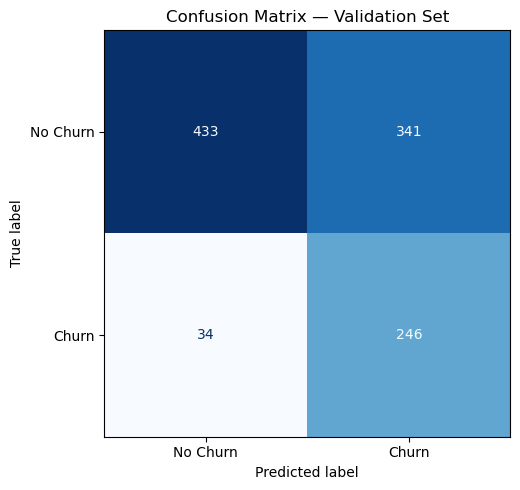

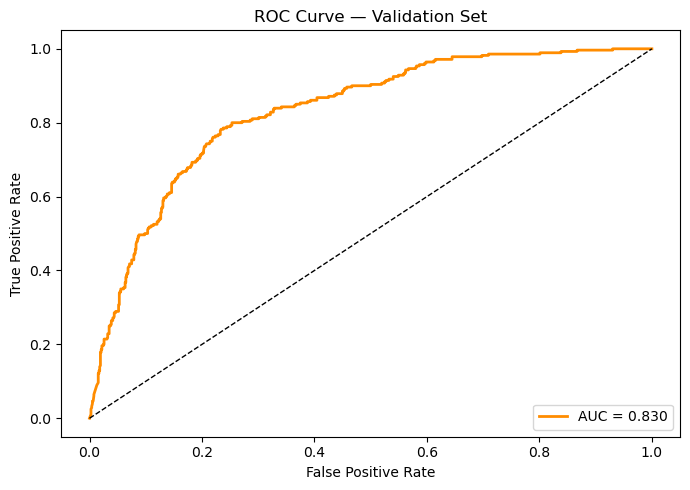

INFO:sagemaker:Deleting endpoint configuration with name: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-14-41-462
INFO:sagemaker:Deleting endpoint with name: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-14-41-462



Endpoint deleted.


In [9]:
from sagemaker.serializers import CSVSerializer

# Redeploy with correct deserializer
predictor = best_estimator.deploy(
    initial_instance_count=1,
    instance_type='ml.m5.large',
    serializer=CSVSerializer()
)
print("Endpoint deployed:", predictor.endpoint_name)

# Load validation data from S3
val_obj = s3.get_object(Bucket=bucket, Key='validation.csv')
val_df  = pd.read_csv(io.BytesIO(val_obj['Body'].read()), header=None)
val_y   = val_df.iloc[:, 0].values
val_X   = val_df.iloc[:, 1:].values

print(f"Validation set shape : {val_X.shape}")

# Predict in batches — parse response correctly
batch_size  = 500
preds_proba = []
for i in range(0, len(val_X), batch_size):
    batch    = val_X[i:i+batch_size]
    response = predictor.predict(batch)
    # Response comes back as raw string of newline-separated probabilities
    if isinstance(response, bytes):
        response = response.decode('utf-8')
    if isinstance(response, str):
        vals = [float(x.strip()) for x in response.strip().split('\n') if x.strip()]
        preds_proba.extend(vals)
    elif isinstance(response, dict):
        # Handle dict response format
        vals = response.get('predictions', response.get('outputs', []))
        if isinstance(vals[0], dict):
            vals = [v.get('score', v.get('predicted_label', 0)) for v in vals]
        preds_proba.extend(vals)
    else:
        preds_proba.extend(list(response))

preds_proba  = np.array(preds_proba, dtype=float).flatten()
print(f"Predictions count : {len(preds_proba)}")
print(f"Sample predictions: {preds_proba[:5]}")
print(f"Min: {preds_proba.min():.4f}  Max: {preds_proba.max():.4f}")

threshold    = 0.5
preds_binary = (preds_proba >= threshold).astype(int)

# Metrics
print("\n=== Validation Set Results ===")
print(classification_report(val_y, preds_binary, target_names=['No Churn','Churn']))
print(f"ROC AUC  : {roc_auc_score(val_y, preds_proba):.4f}")
print(f"F1 Score : {f1_score(val_y, preds_binary):.4f}")
print(f"Precision: {precision_score(val_y, preds_binary):.4f}")
print(f"Recall   : {recall_score(val_y, preds_binary):.4f}")

# Confusion Matrix
cm  = confusion_matrix(val_y, preds_binary)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=['No Churn','Churn']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(val_y, preds_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'AUC = {roc_auc_score(val_y, preds_proba):.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Validation Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Delete endpoint
predictor.delete_endpoint()
print("\nEndpoint deleted.")

Best threshold : 0.7370
Best F1 Score  : 0.6441

=== Threshold Comparison ===
 Threshold  Precision     Recall         F1
    0.3000     0.3644     0.9643     0.5289
    0.3500     0.3761     0.9429     0.5377
    0.4000     0.3819     0.9179     0.5393
    0.4500     0.4058     0.9000     0.5594
    0.5000     0.4191     0.8786     0.5675
    0.7370     0.5475     0.7821     0.6441 <-- best F1


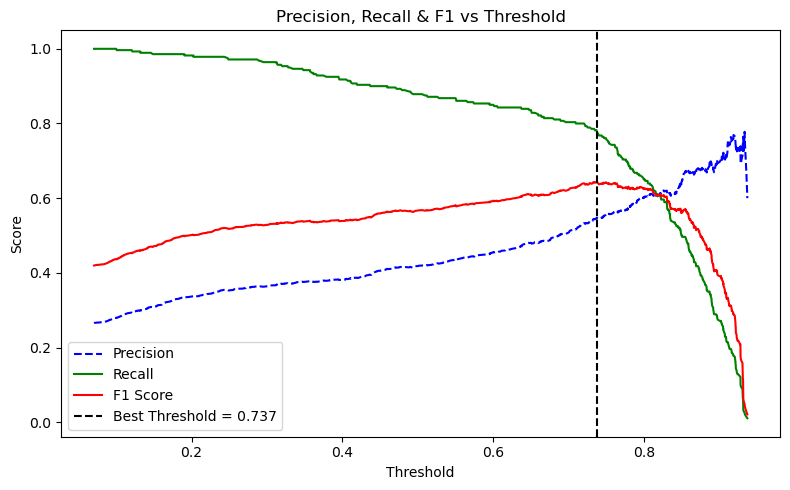


=== Results at Optimal Threshold (0.7370) ===
              precision    recall  f1-score   support

    No Churn       0.91      0.77      0.83       774
       Churn       0.55      0.78      0.64       280

    accuracy                           0.77      1054
   macro avg       0.73      0.77      0.74      1054
weighted avg       0.81      0.77      0.78      1054

ROC AUC  : 0.8304
F1 Score : 0.6441
Precision: 0.5475
Recall   : 0.7821


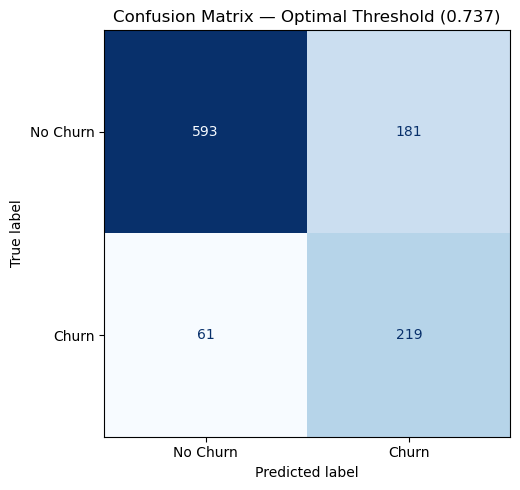

In [10]:
from sklearn.metrics import precision_recall_curve

# Find optimal threshold using F1 score
precisions, recalls, thresholds = precision_recall_curve(val_y, preds_proba)

# Calculate F1 for every threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold_idx = np.argmax(f1_scores)
best_threshold     = thresholds[best_threshold_idx]
best_f1            = f1_scores[best_threshold_idx]

print(f"Best threshold : {best_threshold:.4f}")
print(f"Best F1 Score  : {best_f1:.4f}")

# Show results at different thresholds so you can decide
print("\n=== Threshold Comparison ===")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
for t in [0.3, 0.35, 0.4, 0.45, 0.5, best_threshold]:
    preds_t = (preds_proba >= t).astype(int)
    p = precision_score(val_y, preds_t)
    r = recall_score(val_y, preds_t)
    f = f1_score(val_y, preds_t)
    marker = ' <-- best F1' if abs(t - best_threshold) < 0.001 else ''
    print(f"{t:>10.4f} {p:>10.4f} {r:>10.4f} {f:>10.4f}{marker}")

# Plot Precision-Recall curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1],    'g-',  label='Recall')
plt.plot(thresholds, f1_scores[:-1],  'r-',  label='F1 Score')
plt.axvline(x=best_threshold, color='black', linestyle='--',
            label=f'Best Threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall & F1 vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Apply best threshold
preds_binary_best = (preds_proba >= best_threshold).astype(int)
print(f"\n=== Results at Optimal Threshold ({best_threshold:.4f}) ===")
print(classification_report(val_y, preds_binary_best, target_names=['No Churn','Churn']))
print(f"ROC AUC  : {roc_auc_score(val_y, preds_proba):.4f}")
print(f"F1 Score : {f1_score(val_y, preds_binary_best):.4f}")
print(f"Precision: {precision_score(val_y, preds_binary_best):.4f}")
print(f"Recall   : {recall_score(val_y, preds_binary_best):.4f}")

# Confusion Matrix at best threshold
cm_best = confusion_matrix(val_y, preds_binary_best)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_best,
    display_labels=['No Churn','Churn']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — Optimal Threshold ({best_threshold:.3f})')
plt.tight_layout()
plt.show()

## Final Test Set Evaluation

INFO:sagemaker:Creating model with name: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-21-05-754
INFO:sagemaker:Creating endpoint-config with name telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-21-05-754
INFO:sagemaker:Creating endpoint with name telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-21-05-754


------!Test endpoint: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-21-05-754
Test set shape : (1057, 35)

Using optimal threshold : 0.7370
Predictions count       : 1057

=== Final Test Set Results ===
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82       777
       Churn       0.53      0.77      0.63       280

    accuracy                           0.76      1057
   macro avg       0.71      0.76      0.72      1057
weighted avg       0.80      0.76      0.77      1057

ROC AUC  : 0.8507
F1 Score : 0.6261
Precision: 0.5268
Recall   : 0.7714
Accuracy : 0.7559


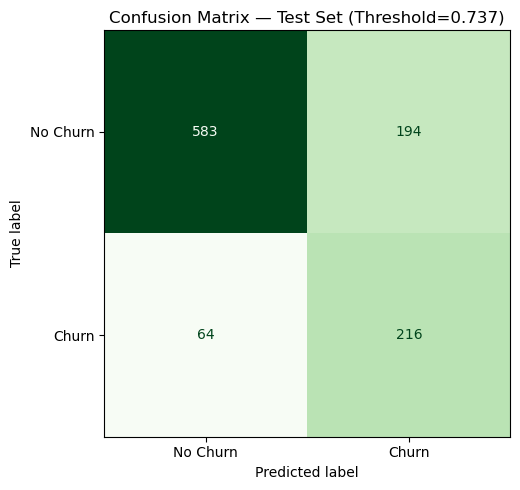

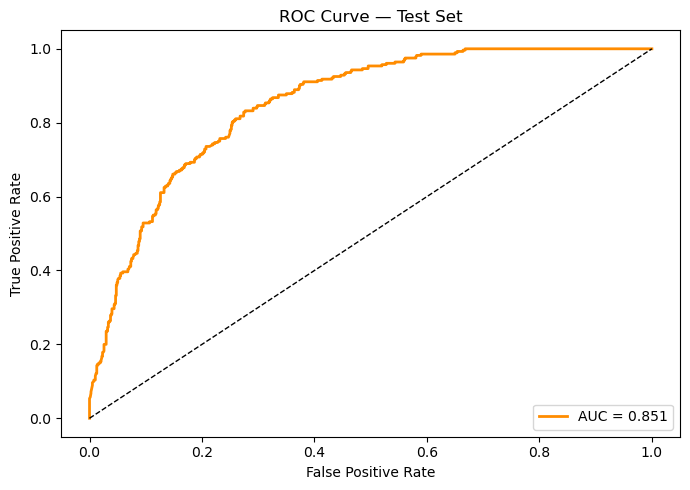

INFO:sagemaker:Deleting endpoint configuration with name: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-21-05-754
INFO:sagemaker:Deleting endpoint with name: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-21-05-754



Test endpoint deleted.


In [11]:
# Redeploy for test set evaluation
predictor_test = best_estimator.deploy(
    initial_instance_count=1,
    instance_type='ml.m5.large',
    serializer=CSVSerializer()
)
print("Test endpoint:", predictor_test.endpoint_name)

# Load test data from S3
test_obj = s3.get_object(Bucket=bucket, Key='test.csv')
test_df  = pd.read_csv(io.BytesIO(test_obj['Body'].read()), header=None)
test_y   = test_df.iloc[:, 0].values
test_X   = test_df.iloc[:, 1:].values

print(f"Test set shape : {test_X.shape}")

# Predict in batches
test_preds_proba = []
for i in range(0, len(test_X), batch_size):
    batch    = test_X[i:i+batch_size]
    response = predictor_test.predict(batch)
    if isinstance(response, bytes):
        response = response.decode('utf-8')
    if isinstance(response, str):
        vals = [float(x.strip()) for x in response.strip().split('\n') if x.strip()]
        test_preds_proba.extend(vals)
    elif isinstance(response, dict):
        vals = response.get('predictions', response.get('outputs', []))
        if isinstance(vals[0], dict):
            vals = [v.get('score', v.get('predicted_label', 0)) for v in vals]
        test_preds_proba.extend(vals)
    else:
        test_preds_proba.extend(list(response))

test_preds_proba  = np.array(test_preds_proba, dtype=float).flatten()

# Use optimal threshold found from validation set
optimal_threshold  = best_threshold
test_preds_binary  = (test_preds_proba >= optimal_threshold).astype(int)

print(f"\nUsing optimal threshold : {optimal_threshold:.4f}")
print(f"Predictions count       : {len(test_preds_proba)}")

# Metrics
print("\n=== Final Test Set Results ===")
print(classification_report(test_y, test_preds_binary, target_names=['No Churn','Churn']))
print(f"ROC AUC  : {roc_auc_score(test_y, test_preds_proba):.4f}")
print(f"F1 Score : {f1_score(test_y, test_preds_binary):.4f}")
print(f"Precision: {precision_score(test_y, test_preds_binary):.4f}")
print(f"Recall   : {recall_score(test_y, test_preds_binary):.4f}")
print(f"Accuracy : {(test_preds_binary == test_y).mean():.4f}")

# Confusion Matrix
cm_test = confusion_matrix(test_y, test_preds_binary)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_test,
    display_labels=['No Churn','Churn']).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f'Confusion Matrix — Test Set (Threshold={optimal_threshold:.3f})')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(test_y, test_preds_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'AUC = {roc_auc_score(test_y, test_preds_proba):.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Delete endpoint
predictor_test.delete_endpoint()
print("\nTest endpoint deleted.")

## Batch Transform

In [12]:
from sagemaker.transformer import Transformer

# Save test features only (no labels) for batch input
test_features = test_df.iloc[:, 1:]
test_features.to_csv('/tmp/batch_input.csv', index=False, header=False)

# Upload to S3
s3.upload_file(
    '/tmp/batch_input.csv', bucket,
    'batch-input/batch_input.csv'
)
batch_s3_input = f's3://{bucket}/batch-input/batch_input.csv'
print("Batch input uploaded:", batch_s3_input)

# Create transformer from best model
transformer = best_estimator.transformer(
    instance_count=1,
    instance_type='ml.m5.xlarge',
    output_path=f's3://{bucket}/batch-output/',
    strategy='MultiRecord',
    assemble_with='Line',
    accept='text/csv'
)

# Run batch transform
transformer.transform(
    data=batch_s3_input,
    data_type='S3Prefix',
    content_type='text/csv',
    split_type='Line',
    job_name=f'telco-churn-batch-{pd.Timestamp.now().strftime("%Y%m%d-%H%M%S")}',
    wait=True,
    logs=False
)

print("Batch Transform complete!")
print(f"Results at: s3://{bucket}/batch-output/")

# Download and inspect results
response    = s3.get_object(Bucket=bucket,
                  Key='batch-output/batch_input.csv.out')
batch_preds = pd.read_csv(io.BytesIO(response['Body'].read()),
                  header=None, names=['ChurnProbability'])

# Apply optimal threshold
batch_preds['ChurnPrediction'] = (batch_preds['ChurnProbability'] >= optimal_threshold).astype(int)
batch_preds['Risk'] = pd.cut(
    batch_preds['ChurnProbability'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print(f"\nTotal customers scored : {len(batch_preds)}")
print(f"Predicted churners     : {batch_preds['ChurnPrediction'].sum()}")
print(f"Predicted churn rate   : {batch_preds['ChurnPrediction'].mean():.1%}")
print(f"\nRisk Distribution:")
print(batch_preds['Risk'].value_counts().sort_index())
print(f"\nSample predictions:")
print(batch_preds.head(10))

INFO:sagemaker:Creating model with name: telco-churn-hpo-20260319-195217-003-614-2026-03-19-20-25-42-964


Batch input uploaded: s3://week8-ali/batch-input/batch_input.csv


INFO:sagemaker:Creating transform job with name: telco-churn-batch-20260319-202543


.................................................................!
Batch Transform complete!
Results at: s3://week8-ali/batch-output/

Total customers scored : 1057
Predicted churners     : 410
Predicted churn rate   : 38.8%

Risk Distribution:
Risk
Low          308
Medium       144
High         149
Very High    456
Name: count, dtype: int64

Sample predictions:
   ChurnProbability  ChurnPrediction       Risk
0          0.266633                0        Low
1          0.669866                0       High
2          0.444742                0     Medium
3          0.806304                1  Very High
4          0.877551                1  Very High
5          0.722934                0  Very High
6          0.825023                1  Very High
7          0.675718                0       High
8          0.381825                0     Medium
9          0.701905                0  Very High
